# Features Analysis EDA
Phân tích chi tiết về label distribution, data quality, và các thống kê khác

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 1. Load Data

In [2]:
# Load data
df = pd.read_csv('../../data/raw/data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData info:")
print(df.info())

Dataset shape: (4736, 26)

Column names: ['id', 'user_name', 'timestamp_post', 'post_message', 'label', 'num_char', 'num_emoji', 'num_url', 'num_hashtag', 'num_post', 'num_real', 'num_fake', 'post_ratio', 'num_like', 'num_cmt', 'num_share', 'pixel', 'image', 'num_image', 'hour', 'weekday', 'day', 'month', 'year', 'time', 'min']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4736 entries, 0 to 4735
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              4736 non-null   int64  
 1   user_name       4736 non-null   object 
 2   timestamp_post  4736 non-null   int64  
 3   post_message    4736 non-null   object 
 4   label           4736 non-null   int64  
 5   num_char        4736 non-null   int64  
 6   num_emoji       4736 non-null   int64  
 7   num_url         4736 non-null   int64  
 8   num_hashtag     4736 non-null   int64  
 9   num_post        4736 non-null   int64  
 10  num_re

## 2. Label Distribution (CRITICAL!)

In [3]:
print("=" * 60)
print("LABEL DISTRIBUTION")
print("=" * 60)

# Count
label_counts = df['label'].value_counts().sort_index()
print("\nAbsolute counts:")
for label, count in label_counts.items():
    label_name = "Real" if label == 0 else "Fake"
    print(f"  {label_name}: {count}")

# Percentage
label_pct = df['label'].value_counts(normalize=True).sort_index() * 100
print("\nPercentage:")
for label, pct in label_pct.items():
    label_name = "Real" if label == 0 else "Fake"
    print(f"  {label_name}: {pct:.2f}%")

# Imbalance ratio
imbalance_ratio = label_counts[0] / label_counts[1]
print(f"\nImbalance ratio (Real:Fake): {imbalance_ratio:.2f}:1")
print(f"\n⚠️ IMPORTANT: Data is IMBALANCED!")
print(f"   - Must use class_weight='balanced'")
print(f"   - Must use AUC metric (not Accuracy)")
print(f"   - Must use stratified train/test split")

LABEL DISTRIBUTION

Absolute counts:
  Real: 3929
  Fake: 807

Percentage:
  Real: 82.96%
  Fake: 17.04%

Imbalance ratio (Real:Fake): 4.87:1

⚠️ IMPORTANT: Data is IMBALANCED!
   - Must use class_weight='balanced'
   - Must use AUC metric (not Accuracy)
   - Must use stratified train/test split


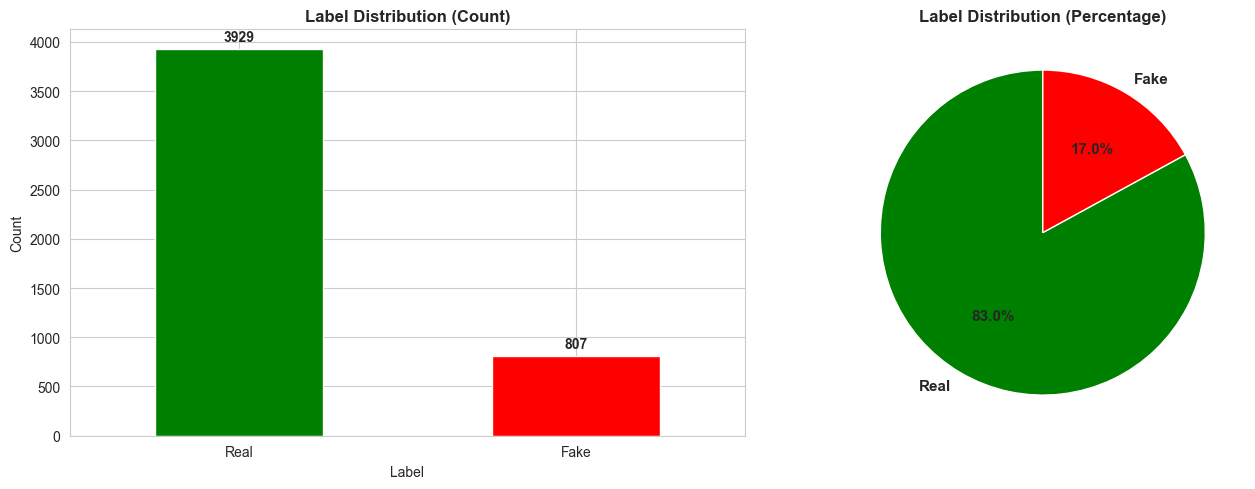

In [5]:
# Visualization: Bar chart
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['green', 'red']
labels_text = ['Real', 'Fake']
label_counts.plot(kind='bar', ax=ax[0], color=colors)
ax[0].set_title('Label Distribution (Count)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Label')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(labels_text, rotation=0)
# Add value labels on bars
for i, v in enumerate(label_counts):
    ax[0].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
ax[1].pie(label_counts, labels=labels_text, autopct='%1.1f%%',
          colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax[1].set_title('Label Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()

## 3. Dataset Overview

In [6]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nTotal samples: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"\nColumn breakdown:")
for col in df.columns:
    dtype = df[col].dtype
    non_null = df[col].notna().sum()
    null = df[col].isna().sum()
    print(f"  {col}: {dtype} ({non_null} non-null, {null} null)")

DATASET OVERVIEW

Total samples: 4736
Number of columns: 26

Column breakdown:
  id: int64 (4736 non-null, 0 null)
  user_name: object (4736 non-null, 0 null)
  timestamp_post: int64 (4736 non-null, 0 null)
  post_message: object (4736 non-null, 0 null)
  label: int64 (4736 non-null, 0 null)
  num_char: int64 (4736 non-null, 0 null)
  num_emoji: int64 (4736 non-null, 0 null)
  num_url: int64 (4736 non-null, 0 null)
  num_hashtag: int64 (4736 non-null, 0 null)
  num_post: int64 (4736 non-null, 0 null)
  num_real: int64 (4736 non-null, 0 null)
  num_fake: int64 (4736 non-null, 0 null)
  post_ratio: float64 (4736 non-null, 0 null)
  num_like: int64 (4736 non-null, 0 null)
  num_cmt: int64 (4736 non-null, 0 null)
  num_share: int64 (4736 non-null, 0 null)
  pixel: int64 (4736 non-null, 0 null)
  image: int64 (4736 non-null, 0 null)
  num_image: int64 (4736 non-null, 0 null)
  hour: int64 (4736 non-null, 0 null)
  weekday: int64 (4736 non-null, 0 null)
  day: int64 (4736 non-null, 0 null)
 

## 4. Missing Values Analysis

In [7]:
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

missing_data = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing': missing_data.values,
    'Percentage': missing_pct.values
}).sort_values('Missing', ascending=False)

print("\n")
print(missing_df.to_string(index=False))

if missing_data.sum() > 0:
    print(f"\n⚠️ Total missing values: {missing_data.sum()}")
else:
    print(f"\n✅ No missing values")

MISSING VALUES ANALYSIS


        Column  Missing  Percentage
            id        0         0.0
     user_name        0         0.0
          time        0         0.0
          year        0         0.0
         month        0         0.0
           day        0         0.0
       weekday        0         0.0
          hour        0         0.0
     num_image        0         0.0
         image        0         0.0
         pixel        0         0.0
     num_share        0         0.0
       num_cmt        0         0.0
      num_like        0         0.0
    post_ratio        0         0.0
      num_fake        0         0.0
      num_real        0         0.0
      num_post        0         0.0
   num_hashtag        0         0.0
       num_url        0         0.0
     num_emoji        0         0.0
      num_char        0         0.0
         label        0         0.0
  post_message        0         0.0
timestamp_post        0         0.0
           min        0         0.0

✅

## 5. Duplicate Analysis

In [9]:
print("=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)

# Check all column duplicates
all_dup = df.duplicated().sum()
print(f"\nFull row duplicates: {all_dup}")

# Check text duplicates (most important)
text_dup = df.duplicated(subset=['post_message']).sum()
print(f"Text duplicates: {text_dup}")

if text_dup > 0:
    print(f"\n⚠️ IMPORTANT: {text_dup} duplicate texts found!")
    print(f"   These must be removed BEFORE train/test split")
    print(f"   Otherwise: data leakage → inflated AUC")
    
    # Show some examples
    print(f"\nDuplicate distribution:")
    dup_texts = df[df.duplicated(subset=['post_message'], keep=False)]['post_message']
    print(f"  Total rows with duplicates: {len(dup_texts)}")
else:
    print(f"\n✅ No duplicate texts")

DUPLICATE ANALYSIS

Full row duplicates: 0
Text duplicates: 0

✅ No duplicate texts


## 6. Data Quality Summary

In [10]:
# Comprehensive quality check
print("\n" + "=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)

quality_checks = {
    "Missing values": df.isnull().sum().sum(),
    "Empty text": (df['text'].str.strip() == '').sum() if 'text' in df.columns else 0,
    "Duplicate rows": df.duplicated().sum(),
    "Duplicate texts": df.duplicated(subset=['text']).sum() if 'text' in df.columns else 0,
}

print("\n")
for check, count in quality_checks.items():
    status = "✅" if count == 0 else "⚠️"
    print(f"{status} {check}: {count}")


DATA QUALITY SUMMARY


✅ Missing values: 0
✅ Empty text: 0
✅ Duplicate rows: 0
✅ Duplicate texts: 0


## 7. Class Distribution Visualization

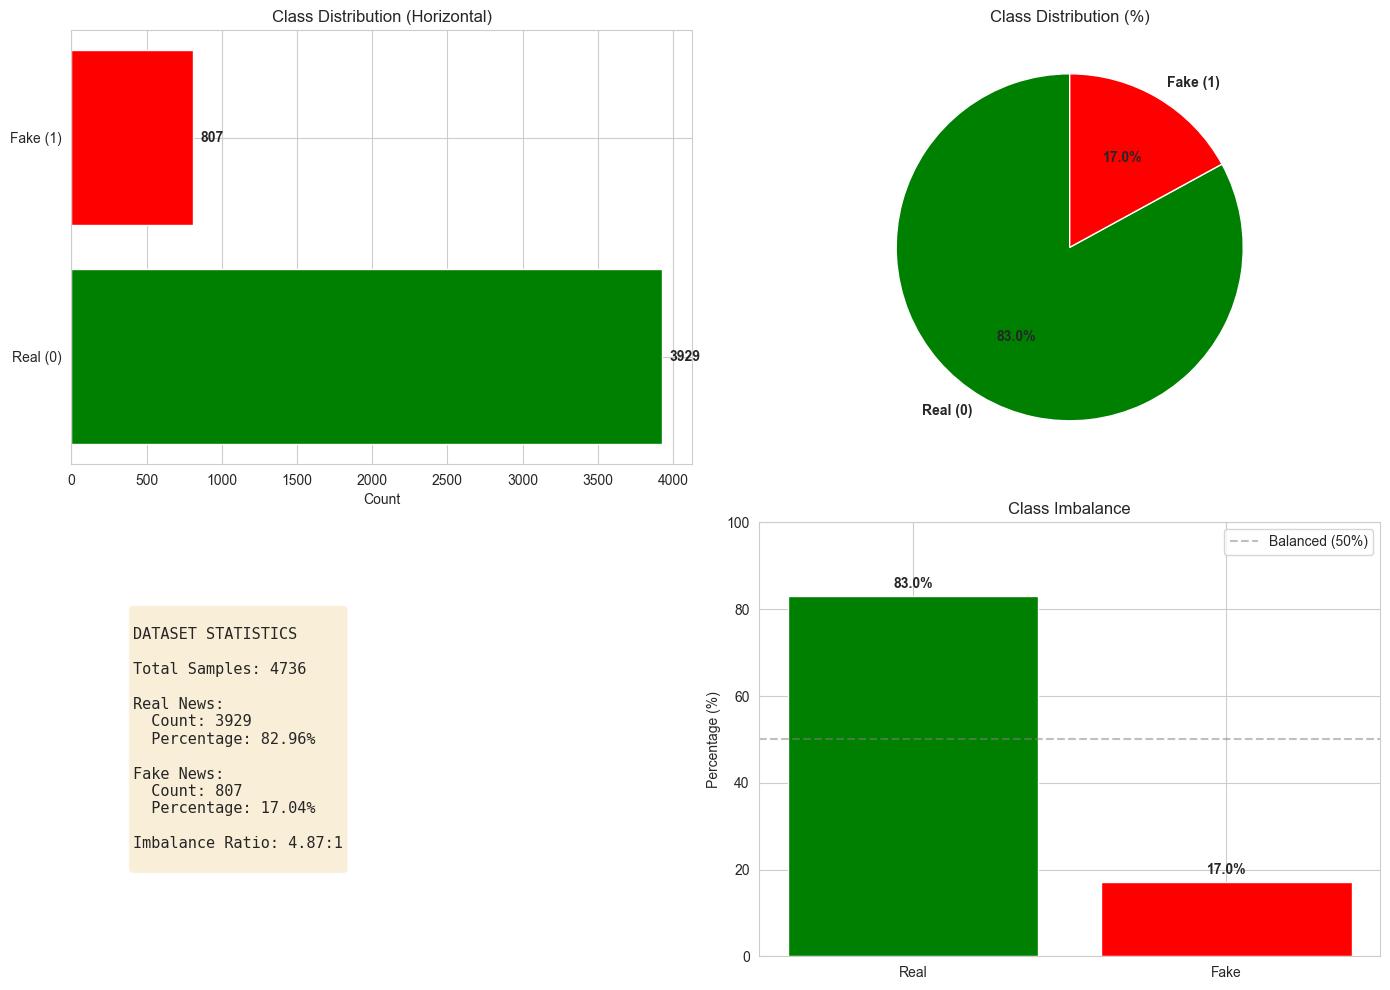

In [12]:
# More detailed class distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart horizontal
label_names = ['Real (0)', 'Fake (1)']
counts = [label_counts[0], label_counts[1]]
axes[0, 0].barh(label_names, counts, color=['green', 'red'])
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_title('Class Distribution (Horizontal)')
for i, v in enumerate(counts):
    axes[0, 0].text(v + 50, i, str(v), va='center', fontweight='bold')

# 2. Pie chart
axes[0, 1].pie(counts, labels=label_names, autopct='%1.1f%%',
               colors=['green', 'red'], startangle=90,
               textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[0, 1].set_title('Class Distribution (%)')

# 3. Text info
axes[1, 0].axis('off')
info_text = f"""
DATASET STATISTICS

Total Samples: {len(df)}

Real News:
  Count: {label_counts[0]}
  Percentage: {label_pct[0]:.2f}%

Fake News:
  Count: {label_counts[1]}
  Percentage: {label_pct[1]:.2f}%

Imbalance Ratio: {imbalance_ratio:.2f}:1
"""
axes[1, 0].text(0.1, 0.5, info_text, fontsize=11, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Imbalance visualization
ratio_data = [label_pct[0], label_pct[1]]
axes[1, 1].bar(['Real', 'Fake'], ratio_data, color=['green', 'red'])
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].set_title('Class Imbalance')
axes[1, 1].set_ylim([0, 100])
for i, v in enumerate(ratio_data):
    axes[1, 1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1, 1].axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Balanced (50%)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 8. Class Weight Calculation

In [13]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(df['label']),
    y=df['label']
)

print("=" * 60)
print("CLASS WEIGHT CALCULATION")
print("=" * 60)
print("\nFor balanced training (handling imbalance):")
print(f"  Class 0 (Real): {class_weights[0]:.4f}")
print(f"  Class 1 (Fake): {class_weights[1]:.4f}")

print(f"\nUsage in training:")
print(f"  class_weight = {{{0}: {class_weights[0]:.4f}, {1}: {class_weights[1]:.4f}}}")
print(f"\nInterpretation:")
print(f"  Fake samples will be weighted {class_weights[1]/class_weights[0]:.2f}x more than Real")
print(f"  This compensates for imbalance during training")

CLASS WEIGHT CALCULATION

For balanced training (handling imbalance):
  Class 0 (Real): 0.6027
  Class 1 (Fake): 2.9343

Usage in training:
  class_weight = {0: 0.6027, 1: 2.9343}

Interpretation:
  Fake samples will be weighted 4.87x more than Real
  This compensates for imbalance during training


## 9. Train/Test Split Strategy

In [14]:
print("=" * 60)
print("RECOMMENDED TRAIN/TEST SPLIT")
print("=" * 60)

# Simulate stratified split
test_pct = 0.2
val_pct = 0.1
train_pct = 1.0 - test_pct - val_pct

# Samples per split
total = len(df)
train_samples = int(total * train_pct)
val_samples = int(total * val_pct)
test_samples = total - train_samples - val_samples

# Real/Fake breakdown
real_count = label_counts[0]
fake_count = label_counts[1]

print(f"\nSplit strategy: {train_pct*100:.0f}% Train / {val_pct*100:.0f}% Val / {test_pct*100:.0f}% Test")
print(f"\nTotal samples: {total}")
print(f"\nTrain set:")
print(f"  Total: {train_samples}")
print(f"  Real ({int(real_count * train_pct)}): {int(real_count * train_pct)/train_samples*100:.1f}%")
print(f"  Fake ({int(fake_count * train_pct)}): {int(fake_count * train_pct)/train_samples*100:.1f}%")

print(f"\nVal set:")
print(f"  Total: {val_samples}")
print(f"  Real ({int(real_count * val_pct)}): {int(real_count * val_pct)/val_samples*100:.1f}%")
print(f"  Fake ({int(fake_count * val_pct)}): {int(fake_count * val_pct)/val_samples*100:.1f}%")

print(f"\nTest set:")
print(f"  Total: {test_samples}")
print(f"  Real ({int(real_count * test_pct)}): {int(real_count * test_pct)/test_samples*100:.1f}%")
print(f"  Fake ({int(fake_count * test_pct)}): {int(fake_count * test_pct)/test_samples*100:.1f}%")

print(f"\n✅ Use StratifiedKFold or stratified_split to maintain ratio!")

RECOMMENDED TRAIN/TEST SPLIT

Split strategy: 70% Train / 10% Val / 20% Test

Total samples: 4736

Train set:
  Total: 3315
  Real (2750): 83.0%
  Fake (564): 17.0%

Val set:
  Total: 473
  Real (392): 82.9%
  Fake (80): 16.9%

Test set:
  Total: 948
  Real (785): 82.8%
  Fake (161): 17.0%

✅ Use StratifiedKFold or stratified_split to maintain ratio!


## 10. Comprehensive Summary Report

In [16]:
import json

# Create comprehensive report
report = {
    "dataset_info": {
        "total_samples": len(df),
        "num_columns": len(df.columns),
        "columns": df.columns.tolist()
    },
    "label_distribution": {
        "real": int(label_counts[0]),
        "fake": int(label_counts[1]),
        "real_percentage": round(float(label_pct[0]), 2),
        "fake_percentage": round(float(label_pct[1]), 2),
        "imbalance_ratio": round(float(imbalance_ratio), 2)
    },
    "data_quality": {
        "missing_values": int(df.isnull().sum().sum()),
        "empty_texts": int((df['text'].str.strip() == '').sum()) if 'text' in df.columns else 0,
        "duplicate_rows": int(df.duplicated().sum()),
        "duplicate_texts": int(df.duplicated(subset=['text']).sum()) if 'text' in df.columns else 0
    },
    "class_weights": {
        "real": round(float(class_weights[0]), 4),
        "fake": round(float(class_weights[1]), 4)
    },
    "recommended_actions": [
        "Remove duplicate texts before train/test split",
        "Use stratified train/test/val split to maintain class ratio",
        "Use class_weight='balanced' during model training",
        "Use AUC and F1 as primary metrics (NOT Accuracy)",
        "Use StratifiedKFold for cross-validation"
    ]
}

print("\n" + "=" * 60)
print("COMPREHENSIVE FEATURE ANALYSIS REPORT")
print("=" * 60)
print(json.dumps(report, indent=2, ensure_ascii=False))

print(f"\n✅ Report saved to: ../../eda/features_analysis_report.json")


COMPREHENSIVE FEATURE ANALYSIS REPORT
{
  "dataset_info": {
    "total_samples": 4736,
    "num_columns": 26,
    "columns": [
      "id",
      "user_name",
      "timestamp_post",
      "post_message",
      "label",
      "num_char",
      "num_emoji",
      "num_url",
      "num_hashtag",
      "num_post",
      "num_real",
      "num_fake",
      "post_ratio",
      "num_like",
      "num_cmt",
      "num_share",
      "pixel",
      "image",
      "num_image",
      "hour",
      "weekday",
      "day",
      "month",
      "year",
      "time",
      "min"
    ]
  },
  "label_distribution": {
    "real": 3929,
    "fake": 807,
    "real_percentage": 82.96,
    "fake_percentage": 17.04,
    "imbalance_ratio": 4.87
  },
  "data_quality": {
    "missing_values": 0,
    "empty_texts": 0,
    "duplicate_rows": 0,
    "duplicate_texts": 0
  },
  "class_weights": {
    "real": 0.6027,
    "fake": 2.9343
  },
  "recommended_actions": [
    "Remove duplicate texts before train/test spli

## 11. Next Steps

In [18]:
print("\n" + "=" * 60)
print("NEXT STEPS")
print("=" * 60)

print("""
1. DATA CLEANING (after EDA)
    Remove duplicates
    Clean URLs, HTML, special characters
    Replace underscores with spaces
    Save cleaned data

2. PREPROCESSING (before model training)
    Stratified train/test split (80/20)
    Further split train into train/val (80/20)
    Prepare BERT tokenizer inputs

3. MODEL TRAINING
    Use class_weight='balanced'
    Monitor AUC (not Accuracy)
    Use stratified K-fold validation

4. EVALUATION METRICS
    Primary: AUC-ROC
    Secondary: F1, Precision, Recall
    Generate confusion matrix
    Plot ROC & PR curves
""")


NEXT STEPS

1. DATA CLEANING (after EDA)
    Remove duplicates
    Clean URLs, HTML, special characters
    Replace underscores with spaces
    Save cleaned data

2. PREPROCESSING (before model training)
    Stratified train/test split (80/20)
    Further split train into train/val (80/20)
    Prepare BERT tokenizer inputs

3. MODEL TRAINING
    Use class_weight='balanced'
    Monitor AUC (not Accuracy)
    Use stratified K-fold validation

4. EVALUATION METRICS
    Primary: AUC-ROC
    Secondary: F1, Precision, Recall
    Generate confusion matrix
    Plot ROC & PR curves

